## Installations et imports de librairies

In [18]:
pip install zuko POT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.6 MB/s eta 0:00:00


In [19]:
!git clone https://github.com/pdenailly/score-da-colab.git
%cd score-da-colab
import sys
sys.path.append(".")

Cloning into 'score-da-colab'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 45 (delta 15), reused 25 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 1.19 MiB | 4.70 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/score-da-colab/score-da-colab/score-da-colab/score-da-colab


In [22]:
#%load_ext autoreload
#%autoreload 2

import itertools
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import argparse

from pathlib import Path
from typing import *
import os

from sda.mcs import *
from sda.score import *
from sda.utils import *

from utils import *

## Système Lorentz 1963

### Processus de génération

### Processus de génération des données

Le système de Lorenz 1963 est simulé pour générer des trajectoires chaotiques :

1. **Chaîne de Markov** : Création d'un modèle `NoisyLorenz63` avec pas de temps `dt=0.025`
2. **Conditions initiales** : Échantillonnage de 1024 points de départ depuis la distribution a priori
3. **Simulation** : Génération de trajectoires longues (1024 pas de temps)
4. **Prétraitement** : Normalisation des données pour l'entraînement du modèle de score
5. **Division** : Séparation en ensembles d'entraînement (80%), validation (10%) et test (10%)

Les données finales ont la forme `(n_trajectoires, longueur_temporelle, 3_variables)`.

In [23]:
chain = make_chain()

x = chain.prior((1024,))
x = chain.trajectory(x, length=1024, last=True)
x = chain.trajectory(x, length=1024)
x = chain.preprocess(x)
x = x.transpose(0, 1)

i = int(0.8 * len(x))
j = int(0.9 * len(x))

train_data = x[:i]
valid_data = x[i:j]
test_data = x[j:]

### Visualisation de 15 trajectoires d'entraînement

### Visualisation des trajectoires d'entraînement

Cette visualisation montre 15 trajectoires du système de Lorenz sous forme de nuages de points 3D :

- **Axes** : Variables normalisées a, b, c (correspondant aux coordonnées x, y, z du système physique)
- **Représentation** : Chaque trajectoire est un nuage de points colorés différemment
- **Échelle** : Données prétraitées dans l'espace d'entraînement du modèle
- **Objectif** : Vérifier la diversité des trajectoires et la structure chaotique de l'attracteur

Le célèbre "papillon" de Lorenz devrait être visible dans la distribution des points.

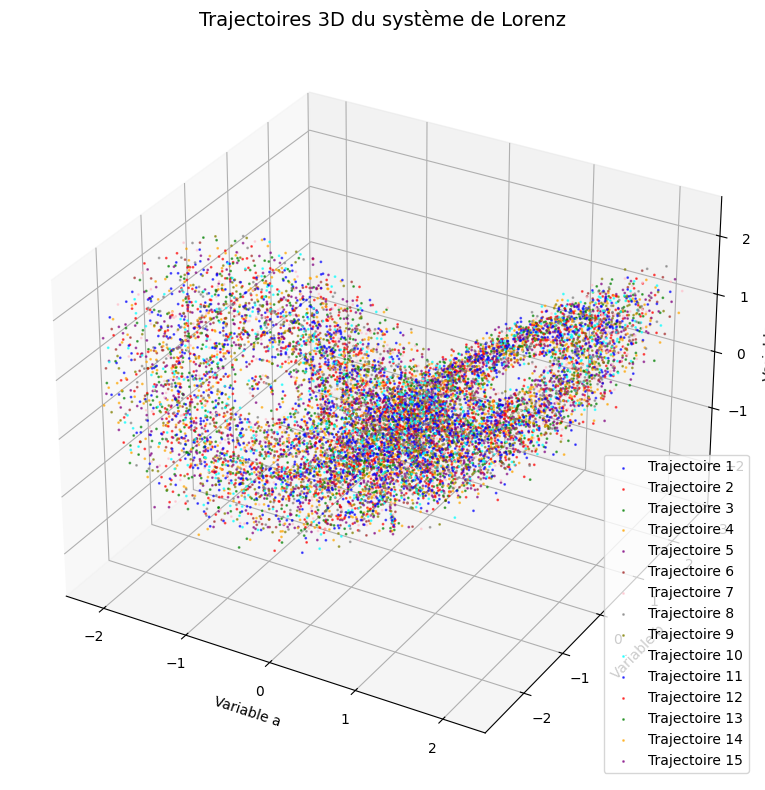

Nombre de trajectoires affichées: 15
Points par trajectoire: 819
Forme totale des données: torch.Size([819, 1024, 3])


In [24]:
# Visualization du train_data

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Nombre de trajectoires à afficher
n_trajectories = 15

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Couleurs pour différentes trajectoires
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

for i in range(n_trajectories):
    traj = train_data[:, i, :]
    ax.scatter(traj[:, 0], traj[:, 1], traj[:, 2],
               c=colors[i % len(colors)],
               s=1,
               alpha=0.6,
               label=f'Trajectoire {i+1}')

ax.set_title('Trajectoires 3D du système de Lorenz', fontsize=14)
ax.set_xlabel('Variable a')
ax.set_ylabel('Variable b')
ax.set_zlabel('Variable c')

ax.legend()
ax.grid(True, alpha=0.3)

# Ajuster les limites pour une meilleure visualisation
ax.set_xlim([train_data[:, :, 0].min(), train_data[:, :, 0].max()])
ax.set_ylim([train_data[:, :, 1].min(), train_data[:, :, 1].max()])
ax.set_zlim([train_data[:, :, 2].min(), train_data[:, :, 2].max()])

plt.tight_layout()
plt.show()

print(f"Nombre de trajectoires affichées: {n_trajectories}")
print(f"Points par trajectoire: {train_data.shape[0]}")
print(f"Forme totale des données: {train_data.shape}")

## Entraînement d'un modèle de Score

### Dataset en mémoire pour l'entraînement

La classe `TrajectoryDataset` du package sda originale attend un fichier HDF5 sur disque. Ell permet de fournir les données d'entraînement et de validation au modèle de score. Pour travailler directement avec les données générées en mémoire dans ce notebook, nous créons un wrapper `InMemoryTrajectoryDataset` qui :

- Accepte des tenseurs PyTorch directement en entrée
- Applique le fenêtrage temporel et l'aplatissement comme l'original
- Permet l'entraînement sans sauvegarde/chargement de fichiers

In [25]:
from torch.utils.data import Dataset

class InMemoryTrajectoryDataset(Dataset):
    def __init__(self, data, window=None, flatten=False):
        self.data = data
        self.window = window
        self.flatten = flatten

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]

        if self.window is not None:
            start = torch.randint(0, len(x) - self.window + 1, size=())
            x = torch.narrow(x, dim=0, start=start.item(), length=self.window)

        if self.flatten:
            x = x.flatten(0, 1)

        return x, {}


### Modèle de score local avec k = 2

Un premier entraînement avec un modèle de score est appliqué avec une fenêtre de taille 5, ce qui permet de prendre un compte un k = 2. L'entraînement sera donc effectué dans un voisinage très local.

In [26]:
LOCAL_CONFIG = {
    # Architecture
    'window': 5,
    'embedding': 32,
    'width': 256,
    'depth': 5,
    'activation': 'SiLU',
    # Training
    'epochs': 2048,
    'batch_size': 64,
    'optimizer': 'AdamW',
    'learning_rate': 1e-3,
    'weight_decay': 1e-3,
    'scheduler': 'linear',
}


# Network
window = LOCAL_CONFIG['window']
score_2 = make_local_score(**LOCAL_CONFIG)
sde_2 = VPSDE(score_2.kernel, shape=(window * 3,)).cuda()

# Data
trainset = InMemoryTrajectoryDataset(train_data, window=window, flatten=True)
validset = InMemoryTrajectoryDataset(valid_data, window=window, flatten=True)

print(f"Training samples: {len(trainset)}")
print(f"Validation samples: {len(validset)}")

# Training
generator = loop(
    sde_2,
    trainset,
    validset,
    **LOCAL_CONFIG,
    device='cuda',
)

for loss_train, loss_valid, lr in generator:
    pass

print("Training finished!")


Training samples: 819
Validation samples: 102


100%|█████████████| 2048/2048 [04:43<00:00,  7.23it/s, lr=4.88e-7, lt=0.0875, lv=0.0889]


Training finished!


### Modèle de score local avec k = 4

Un premier entraînement avec un modèle de score est appliqué avec une fenêtre de taille 9, ce qui permet de prendre un compte un k = 4.

In [ ]:
LOCAL_CONFIG = {
    # Architecture
    'window': 9,
    'embedding': 32,
    'width': 256,
    'depth': 5,
    'activation': 'SiLU',
    # Training
    'epochs': 2048,
    'batch_size': 64,
    'optimizer': 'AdamW',
    'learning_rate': 1e-3,
    'weight_decay': 1e-3,
    'scheduler': 'linear',
}


# Network
window = LOCAL_CONFIG['window']
score_4 = make_local_score(**LOCAL_CONFIG)
sde_4 = VPSDE(score_4.kernel, shape=(window * 3,)).cuda()

# Data
trainset = InMemoryTrajectoryDataset(train_data, window=window, flatten=True)
validset = InMemoryTrajectoryDataset(valid_data, window=window, flatten=True)

print(f"Training samples: {len(trainset)}")
print(f"Validation samples: {len(validset)}")

# Training
generator = loop(
    sde_4,
    trainset,
    validset,
    **LOCAL_CONFIG,
    device='cuda',
)

for loss_train, loss_valid, lr in generator:
    pass

print("Training finished!")


Training samples: 819
Validation samples: 102


100%|█████████████| 2048/2048 [04:04<00:00,  8.38it/s, lr=4.88e-7, lt=0.0558, lv=0.0665]


Training finished!


## Evaluation

Création de deux types d'observations: une basse fréquence faiblement bruitée (y_lo) et une haute fréquence fortement bruitée (y_hi).

In [27]:
test = test_data[:, :65]
y_lo = torch.normal(test[:, ::8, :1], 0.05)
y_hi = torch.normal(test[:, :, :1], 0.25)

### Génération d'échantillons à partir des observations

Dans les codes ci dessous, nous générons des échantillons à partir d'un set d'observations (y_hi ou y_lo) et un modèle (score_2 ou score_4).

In [28]:
def sample_from_partial_observation(
    score,
    y,
    freq='hi',
    corrections=0,
    n_samples=256,
    steps=64,
    tau=0.25,
    device=None,
):
    chain = make_chain()

    if device is None:
        device = next(score.parameters()).device

    y = y.to(device)
    if freq == 'lo':
        sigma, step = 0.05, 8
    else:
        sigma, step = 0.25, 1

    sde = VPSDE(
        GaussianScore(
            y=y,
            A=lambda x: x[..., ::step, :1],
            std=sigma,
            sde=VPSDE(score, shape=()),
            gamma=3e-2,
        ),
        shape=(65, 3),
    ).to(device)

    x_preprocessed = sde.sample((n_samples,), steps=steps, corrections=corrections, tau=tau).cpu()
    x_postprocessed = chain.postprocess(x_preprocessed)
    return x_preprocessed, x_postprocessed, y.cpu()


def plot_partial_reconstructions(
    x_samples,
    y_obs,
    x_true=None,
    n_plot=5,
    freq='hi',
):
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D

    mean_sample = x_samples.mean(dim=0)
    x_plot = x_samples[:n_plot]

    fig = plt.figure(figsize=(18, 6))

    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    ax1.plot(mean_sample[:, 0], mean_sample[:, 1], mean_sample[:, 2], color='blue', label='Mean sample')
    if x_true is not None:
        ax1.plot(x_true[:, 0], x_true[:, 1], x_true[:, 2], color='black', linestyle='--', label='Vérité')
    ax1.set_title('Trajectoire moyenne reconstruite')
    ax1.set_xlabel('a')
    ax1.set_ylabel('b')
    ax1.set_zlabel('c')
    ax1.legend()

    ax2 = fig.add_subplot(1, 3, 2)
    for k in range(min(n_plot, len(x_plot))):
        ax2.plot(x_plot[k, :, 0].numpy(), alpha=0.5)
    if x_true is not None:
        ax2.plot(x_true[:, 0].numpy(), color='black', linestyle='--', linewidth=2, label='Vérité')
    ax2.scatter(torch.arange(len(y_obs)) * (8 if freq == 'lo' else 1), y_obs[:, 0].numpy(), color='red', s=20, label='Observations')
    ax2.set_title('Projection sur a et observations partielles')
    ax2.set_xlabel('Indice temporel')
    ax2.set_ylabel('a')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(1, 3, 3)
    ax3.plot(mean_sample[:, 0].numpy(), label='Mean a')
    if x_true is not None:
        ax3.plot(x_true[:, 0].numpy(), linestyle='--', color='black', label='True a')
    ax3.scatter(torch.arange(len(y_obs)) * (8 if freq == 'lo' else 1), y_obs[:, 0].numpy(), color='red', s=20, label='Obs a')
    ax3.set_title('Comparaison sur la coordonnée a')
    ax3.set_xlabel('Indice temporel')
    ax3.set_ylabel('a')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


100%|███████████████████████████████████████████████████| 64/64 [00:10<00:00,  6.20it/s]


Échantillons générés : torch.Size([256, 65, 3])


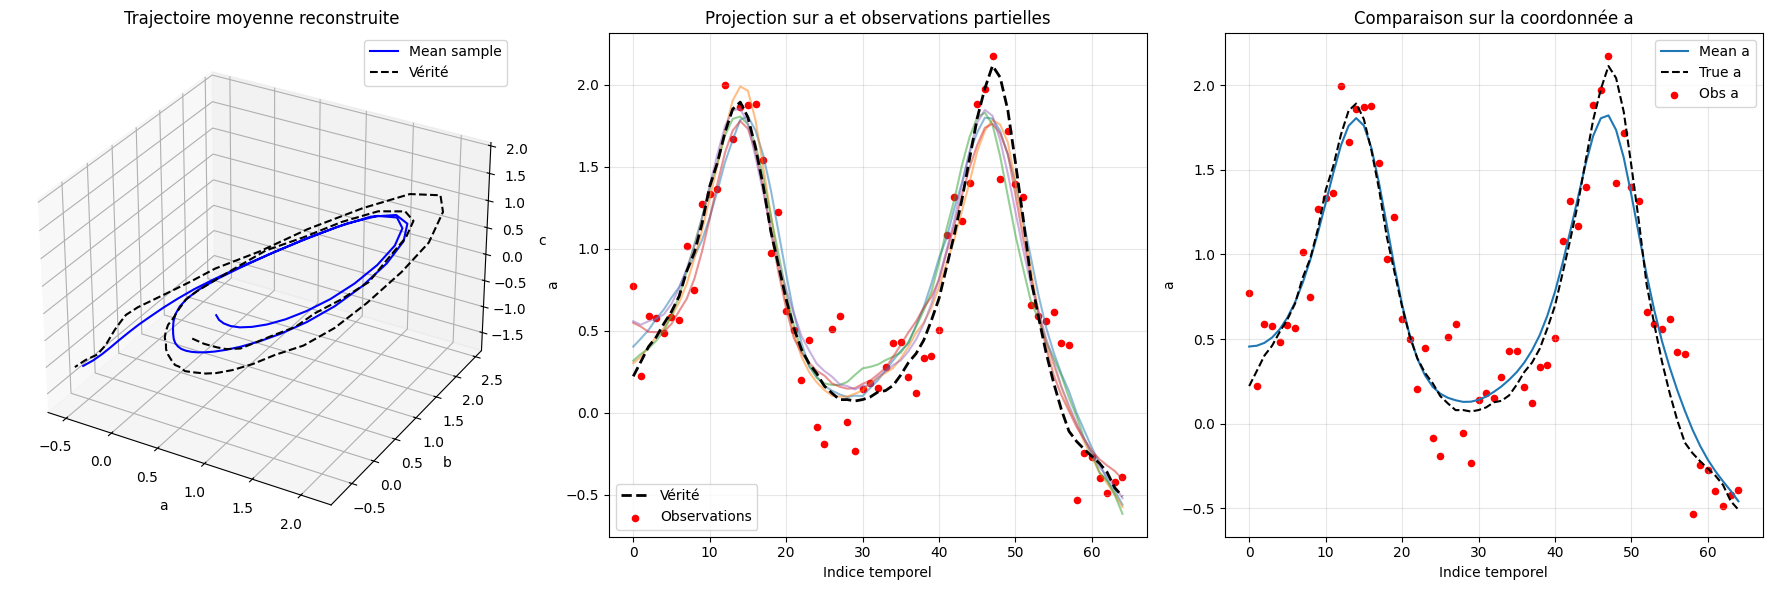

In [29]:
indice_traj = 1
freq = 'hi'
y = y_lo if freq == 'lo' else y_hi
score_ = score_2

# Exemple d'appel : génération conditionnée et visualisation
x_preprocessed, x_postprocessed, y_obs = sample_from_partial_observation(
    score=score_,
    y=y[indice_traj],
    freq=freq,
    corrections=5,
    n_samples=256,
    steps=64,
    tau=0.25,
)

x_true = test[1]

print(f"Échantillons générés : {x_preprocessed.shape}")
plot_partial_reconstructions(
    x_preprocessed,
    y_obs,
    x_true=x_true,
    n_plot=5,
    freq=freq,
)


### Fonction pour évaluation

La fonction `evaluate` évalue le modèle, en utilisant une chaîne de Markov locale et les données de test transférées sur le même appareil que le réseau de score. Elle sert à mesurer la performance du score sur des trajectoires sans perturber l’entraînement.

In [41]:
def evaluate(score, y, freq='hi', corrections=(1, 4)):
    chain = make_chain()
    A = lambda x: chain.preprocess(x)[..., :1]

    device = next(score.parameters()).device
    y = y.to(device)

    if freq == 'lo':
        sigma, step = 0.05, 8
    else:
        sigma, step = 0.25, 1

    sde = VPSDE(
        GaussianScore(
            y=y,
            A=lambda x: x[..., ::step, :1],
            std=sigma,
            sde=VPSDE(score, shape=()),
            gamma=3e-2,
        ),
        shape=(65, 3),
    ).to(device)

    results = {}
    for C in corrections:
        x = sde.sample((512,), steps=64, corrections=C, tau=0.25).cpu()
        x = chain.postprocess(x)

        log_px = log_prior(x).mean().item()
        log_py = log_likelihood(y.cpu(), x, A=A, sigma=sigma, step=step).mean().item()
        results[C] = {'log_px': log_px, 'log_py': log_py}

    return results

In [42]:
freq = 'hi'
y = y_lo if freq == 'lo' else y_hi
score_ = score_2

# accumulation
from collections import defaultdict
acc = defaultdict(lambda: {"log_px": [], "log_py": []})

n_runs = 8  # nombre d'itérations
for _ in range(n_runs):
    idx = torch.randint(0, y.shape[0], (1,)).item()
    results = evaluate(score_, y[idx], freq=freq)
    print(f"Run completed with results: {results}")
    for key, vals in results.items():
        acc[key]["log_px"].append(vals["log_px"])
        acc[key]["log_py"].append(vals["log_py"])

# moyenne
rows = []

for key, vals in acc.items():
    rows.append({
        "correction": key,
        "log_px_mean": sum(vals["log_px"]) / len(vals["log_px"]),
        "log_py_mean": sum(vals["log_py"]) / len(vals["log_py"]),
    })

df = pd.DataFrame(rows).sort_values("correction")

print(df)

100%|███████████████████████████████████████████████████| 64/64 [00:18<00:00,  3.50it/s]


Run completed with results: {1: {'log_px': -1398.2138671875, 'log_py': -6.9888505935668945}, 4: {'log_px': -380.3804931640625, 'log_py': -10.195947647094727}}


100%|███████████████████████████████████████████████████| 64/64 [00:18<00:00,  3.42it/s]


Run completed with results: {1: {'log_px': -1129.30126953125, 'log_py': 0.3928316831588745}, 4: {'log_px': -309.19744873046875, 'log_py': -1.0658727884292603}}


100%|███████████████████████████████████████████████████| 64/64 [00:19<00:00,  3.30it/s]


...

Run completed with results: {1: {'log_px': -1137.627197265625, 'log_py': -2.0142033100128174}, 4: {'log_px': -263.546142578125, 'log_py': -3.075157403945923}}


100%|███████████████████████████████████████████████████| 64/64 [00:19<00:00,  3.26it/s]


Run completed with results: {1: {'log_px': -1309.083984375, 'log_py': 0.8310206532478333}, 4: {'log_px': -378.74102783203125, 'log_py': -2.4450621604919434}}


100%|███████████████████████████████████████████████████| 64/64 [00:19<00:00,  3.26it/s]


Run completed with results: {1: {'log_px': -173018.28125, 'log_py': -2.496650218963623}, 4: {'log_px': -216.01805114746094, 'log_py': -3.978806972503662}}
   correction   log_px_mean  log_py_mean
0           1 -18356.877258    -1.005415
1           4   -263.929785    -3.011996


Testez l'évaluation avec différentes configurations: type d'observations (y_hi, y_lo), la fenêtre utilisée pour le score (k = 2 ou k = 4). Quels sont les impacts constatés du nombre de corrections (C), de la taille de fenêtre (k) et des données sur les scores d'évaluation ?